In [2]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy.ma as ma


/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_82089/261546143.py:8: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  aperture = circular_aperture(pupil_size)


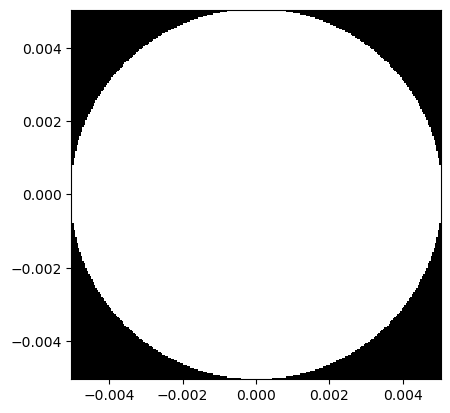

In [3]:
# Set up a pupil size / focal length that are roughly reasonable 
# We should double check these for our system

pupil_size = 10.12e-3 # KiloDM pupil = 10.12 mm
focal_length = 500e-3 # focal length into detector 500 mm

pupil_grid = make_pupil_grid(256, pupil_size)
aperture = circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid)


imshow_field(telescope_pupil, cmap='gray')

/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_82089/4127893158.py:6: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  small_aperture = circular_aperture(small_pupil_size)


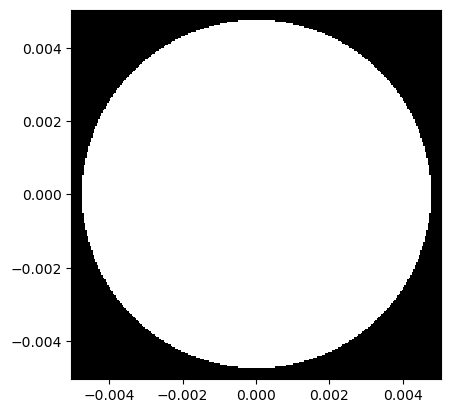

In [4]:
##For testing with smaller aperture
small_pupil_size = 9.5e-3 # KiloDM pupil = 10.12 mm
focal_length = 500e-3 # focal length into detector 500 mm

pupil_grid = make_pupil_grid(256, pupil_size)
small_aperture = circular_aperture(small_pupil_size)
masking_pupil = small_aperture(pupil_grid)


imshow_field(masking_pupil, cmap='gray')

In [5]:
np.sum(telescope_pupil)

OldStyleField(51468.)

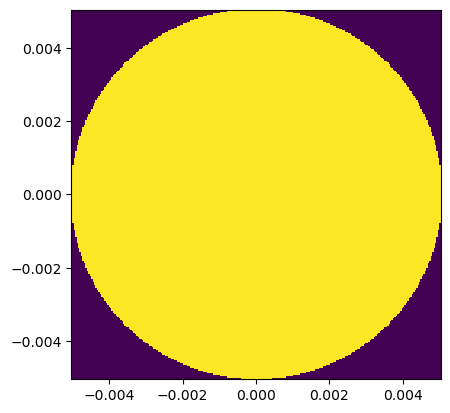

In [6]:
# Build a wavefront at our lab's laser light wavelength 
# Build a focal grid 
# Make a propagation function that moves from focal --> pupil (f2p) and pupil --> focal (p2f)

wavefront = Wavefront(telescope_pupil, wavelength=650e-9)
focal_grid = make_focal_grid(q=16, num_airy=16, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=650e-9)
prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
prop_f2p = FraunhoferPropagator(focal_grid, pupil_grid, focal_length=focal_length)


# Ooooh pupil plane
imshow_field(wavefront.intensity)
pupil_image = wavefront.copy()

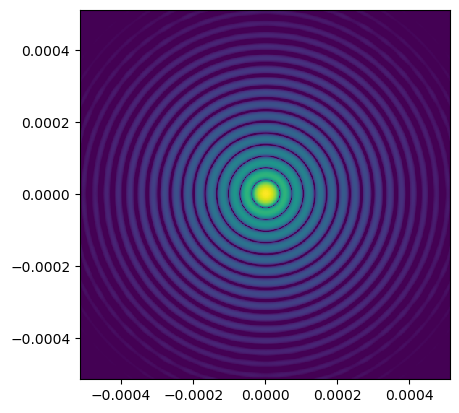

In [7]:
# Ahhh focal plane 

focal_image = prop_p2f.forward(wavefront)
imshow_field(np.log10(focal_image.intensity / focal_image.intensity.max()), vmin=-5)
perfect_focal = focal_image.copy()

OldStyleField(1.55906048)

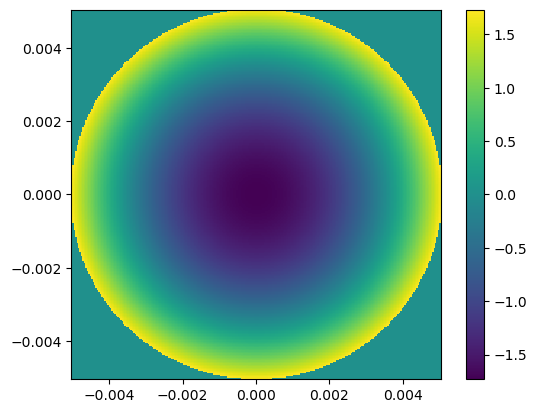

In [8]:
# Using zernike modes built into hcipy we can pull out defocus 
# This is number 3 !!! (change from when I thought it was 4...)

# What is the scale height for the influence function here? 
# One of life's great mysteries 
influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)
imshow_field(influence_functions[3])
plt.colorbar()

# And we can solve that mystery (kind of) by seeing what the dynamic range of this aberration is 
# Looks like it is a nice round number of ... 1.5ish radians? 
(np.max(influence_functions[4]) - np.min(influence_functions[4]))/np.pi

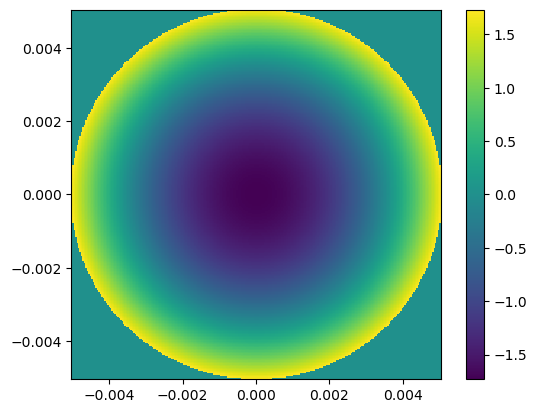

In [9]:
# This tom-foolery is how we can put this aberration into our optical propagation system 
# We're essentially resetting the e field component of the wavefront we defined earlier 
# I think in a neat and ordered world you would wrap this operation in a fancy hcipy wrapper
# but here we thrive in chaos 
scale_factor = 1
pupil_image.electric_field = np.exp(complex(0, 1)*influence_functions[3]*scale_factor)*telescope_pupil

# We have put in a scale factor here -- it doesn't do anything yet but it could ...

imshow_field(pupil_image.phase*telescope_pupil)
plt.colorbar()

In [10]:
# I've defined some convenience functions here 
# For the sake of good coding practices and demos I've made these PEP-8 and numpy docstring conventions
# but frankly this is probably overkill for the 3 lines of code...

def phase_to_m(phase, wv):
    """ Converts phase in radians to meters. 
    Parameters
    ----------
    phase : float or array of floats
        The phase input to be converted in radians. 
    wv: float
        The wavelength to use for conversion in meters. 
    Returns
    -------
    The phase information in units of meters.
    """
    return phase * wv / (2*np.pi)

def p_to_delta(P, f, D): 
    """ Converts P (the peak to valley error in the pupil plane) 
    induced by a delta (the longitudinal distance) offset.
    I.e., given some defocused image we can recontruct what that 
    distance would have been. Note that f and D always need to be
    in the same units -- mm is common, and P and delta will have 
    the same units. 
    Parameters
    ----------
    P : float
        The peak to valley error. 
    f : float
        The focal length leading up to this plane. 
    D : float
        The pupil size/telescope diameter of this plane. 
    Returns
    -------
    The delta defocus that would have been needed to create the P2V 
    we see. 
    """
    return 8 * P * (f/D)**2 


def delta_to_p(delta, f, D):
    """ p_to_delta() but in reverse. Note that f and D always need 
    to be in the same units -- mm is common, and P and delta will 
    have the same units. 
    Parameters
    ----------
    delta : float
        The longitudinal defocus distance. 
    f : float
        The focal length leading up to this plane. 
    D : float
        The pupil size of this plane. 
    Returns
    -------
    The P2V we would see based on the input delta. 
    """
    return -1*delta / (8 * (f/D)**2)

## Have some nicely written up math for the logic we just encapsualted

$\Delta = 8PF^2$ 

(Note, there's a quirk to how you determine sign! Right now the defocus as defined by the ``hcipy`` mode is (+), multiplying this as is by (-1) makes a negative defocus. Example follows...)

where $\Delta$ is the physical longitudinal distance by which the optic is defocused 

$P$ is the peak to valley error in the pupil plane after said defocus 

$F = \frac{f}{D}$ is the F number, or the focal length divided by the telescope diameter (or in our case, pupil size.)

In [11]:
# Now let's test out this relation
# Generate a zernike
example_defocus = influence_functions[3].shaped

# Calculate the P2V in radians 
p2v_radians = np.max(example_defocus) - np.min(example_defocus)
p2v_m = phase_to_m(p2v_radians, 650e-9)

print(f'Our example defocus has a P2V of ~ {np.round(p2v_m*1e9, 1)} nm or {p2v_m/(650e-9)} waves.')
print(f'Our example defocus as a defocus distance of {p_to_delta(p2v_m, focal_length, pupil_size)*1e3} mm')

Our example defocus has a P2V of ~ 358.3 nm or 0.5512615945312378 waves.
Our example defocus as a defocus distance of 6.997454194826208 mm


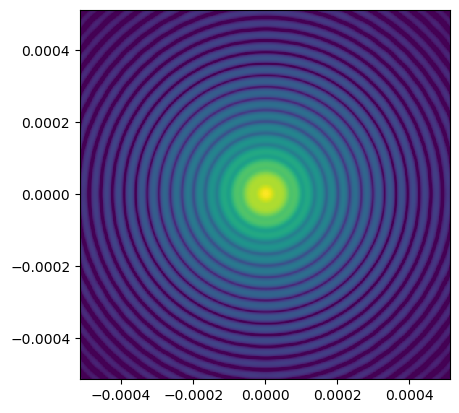

In [12]:
# Okay, what does this look like in the pupil plane? 
focal_image = prop_p2f(pupil_image)
imshow_field(np.log10(focal_image.intensity / focal_image.intensity.max()), vmin=-5)

## Now it's your turn 

1. Run through this notebook, make sure everything makes sense -- ask me lots of questions
2. Go through and generate defocus with different peak to valley errors. 
3. Propogate those through the system and see what they look like in the the focal plane. 
4. calculate the delta distance that would correspond to them. 

*kind reminder*: if you build an aberration with a p2v > 2pi, you will see phase wrapping ... 


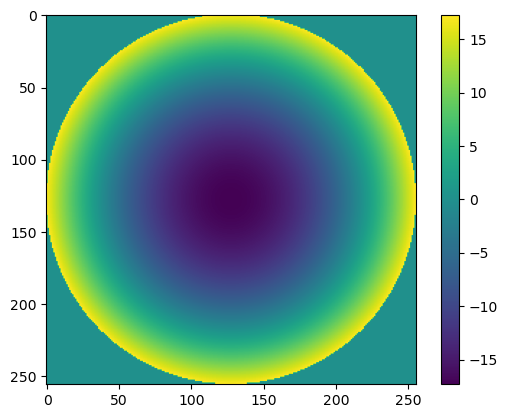

In [13]:
# Let's see this in practice ... 
# Spin up a dramatic defocus 

drama_factor = 10
(np.min(drama_factor*example_defocus) - np.max(drama_factor*example_defocus))/np.pi
plt.imshow(drama_factor*example_defocus)
plt.colorbar()

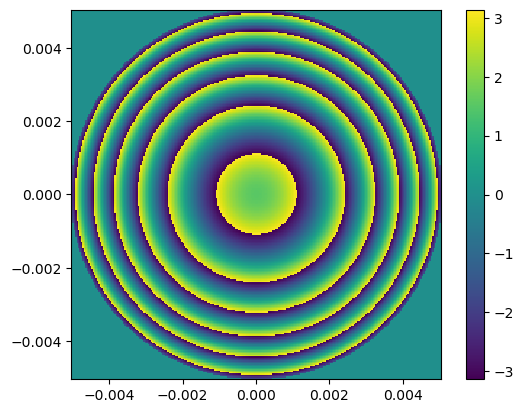

In [14]:
# But oops when we propagate it we lose the full P2V

pupil_image.electric_field = np.exp(complex(0, 1)*influence_functions[3]*drama_factor)*telescope_pupil
imshow_field(pupil_image.phase*telescope_pupil)
plt.colorbar()

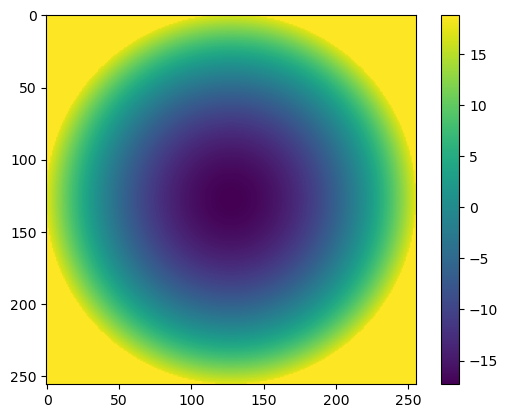

In [15]:
# We can unwrap this with unwrap_phase
# But does something look different than the original input? 
from skimage.restoration import unwrap_phase
unwrapped = unwrap_phase(pupil_image.phase.shaped)
plt.imshow(unwrapped)
plt.colorbar()

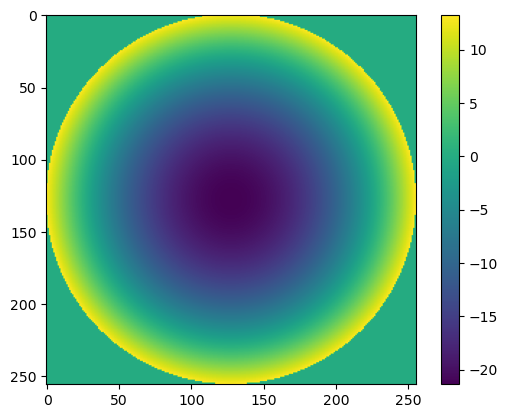

In [16]:
# It should have the same P2V as the original zernike
# but if you want it to match visually you'll need to reset the zero point of the image
plt.imshow((unwrapped - np.mean(unwrapped))*telescope_pupil.shaped)
plt.colorbar()

# Now let's do phase diversity.
1. Spin up an optical aberation. We can throw in a rogue zernike mode to start, but could also be fun to build up a [messy lens](https://docs.hcipy.org/0.3.1/api/hcipy.optics.SurfaceAberration.html)
2. Given some known defocuses and their distances, propagate through the defocus + the aberation, and build a set of focal plane images : defocus distances. 
3. Throw them into Jaren's algorithm and see what happens...

This is where we start pulling content from [Jaren's notebook](https://github.com/KeckObservatory/data_pyao/blob/13-image-sharpening-script-in-python/doc/source/pages/demo_image_sharpening.ipynb) -- note that we are using ``hcipy`` not ``prysm`` so a lot of the optical propagation logic is totally different, but the phase diversity content is the same.

(OldStyleField(-2.10626304), OldStyleField(2.10626304))

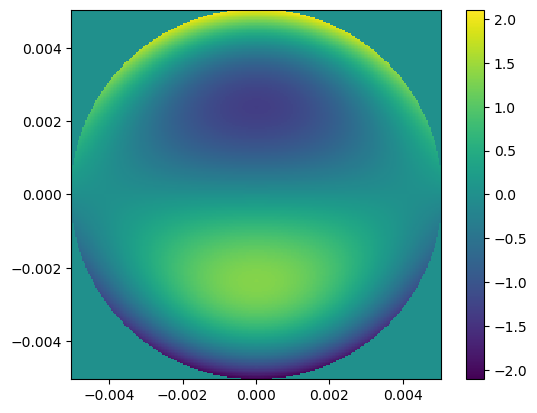

In [17]:
# Let's put in a mild vertical coma/defocus
test_ab = .75 *influence_functions[6]
imshow_field(test_ab)
plt.colorbar()
np.min(test_ab), np.max(test_ab)

P2V of example defocus:  358.3200364453046  nm error


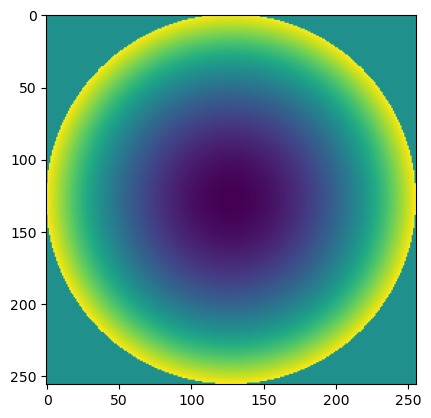

In [18]:
# Remind ourselves what this example defocus looks like

plt.imshow(example_defocus)
p2v_radians = (np.max(example_defocus) - np.min(example_defocus))
p2v_m = phase_to_m(p2v_radians, 650e-9)
print('P2V of example defocus: ', p2v_m*1e9, ' nm error')

In [19]:
#Insert Numpy Docstrings for respective functions
# Function to calculate P2V error and defocus distance
dx_list = [2.0071, 2.0071] 
wavelength=650e-9
D = pupil_size
f = focal_length
def calculate_defocus_params(example_defocus, scale, f, D):
    """
    Calculates P2V error and defocus distance for given defocus phase and scale.
    
    Parameters
    ----------
    example_defocus : np.ndarray
        Array representing the defocus phase.
    scale : float
        Scale factor for the defocus phase.
    f : float
        Focal length of the system.
    D : float
        Size of the pupil.
    
    Returns
    -------
    tuple
        P2V error in radians and defocus distance.
    """
    
    defocus_phase = example_defocus * scale
    print(scale)
    p2v_radians = np.max(defocus_phase) - np.min(defocus_phase)
    p2v_m = phase_to_m(p2v_radians, 650e-9)
    delta = p_to_delta(p2v_m, f, D)
    delta=delta if scale>0 else -1*delta
    return p2v_radians, delta

def propagate_image(defocus_phase, test_ab, telescope_pupil, wavelength):
    """
    Propagates an image using the given defocus phase, test aberration, and telescope pupil.
    
    Parameters
    ----------
    defocus_phase : np.ndarray
        Array representing the defocus phase.
    test_ab : np.ndarray
        Array representing the test aberration.
    telescope_pupil : np.ndarray
        Array representing the telescope pupil.
    wavelength : float
        Wavelength of light in meters.
    
    Returns
    -------
    focal_intensity
        Focal intensity of the propagated image.
    """
    
    # Combine test aberration and defocus phase
    combined_phase = (test_ab + defocus_phase).ravel()
    # Create pupil field with combined phase
    pupil_field = telescope_pupil * np.exp(complex(0, 1)* combined_phase)
     # Create a wavefront object
    wavefront = Wavefront(pupil_field, wavelength)
    # Propagate the wavefront to the focal plane
    focal_field = prop_p2f.forward(wavefront)
    # Calculate the focal intensity
    focal_intensity = np.abs(focal_field.electric_field.reshape(focal_grid.shape))**2
    return focal_intensity

# Function to take the example defocus with the scale and values from other function and return a list(whoo labeled)
#Delta should be a list passed to this function
def generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength):
    """
    Generates defocus lists and calculates PSF for each scale.
    
    Parameters
    ----------
    example_defocus : np.ndarray
        Array representing the example defocus.
    scales : list of float
        List of scales to apply to the defocus phase.
    f : float
        Focal length of the system.
    D : float
        Size of the pupil.
    test_ab : np.ndarray
        Array representing the test aberration.
    telescope_pupil : np.ndarray
        Array representing the telescope pupil.
    wavelength : float
        Wavelength of light in meters.
    
    Returns
    -------
    tuple
        List of PSFs and list of defocus distances.
    """
    psf_list = []
    distance_list = []
  # List to store dx values, same length as distance_list

    # Ensure the shapes are compatible
    example_defocus = example_defocus.reshape(telescope_pupil.shape)
    test_ab = test_ab.reshape(telescope_pupil.shape)
    # Calculate no-defocus image
    no_defocus_phase = np.zeros_like(example_defocus)
    no_defocus_image = propagate_image(no_defocus_phase, test_ab, telescope_pupil, wavelength)
    psf_list.append(no_defocus_image)
    

    for scale in scales:
        #Do something here to recognize that the scale is negative and multiply again by -1, pssoibly if statement
        #if scale is negative, append -1 *delta
        #Directly pass delta to this function
        p2v_radians, delta = calculate_defocus_params(example_defocus, scale, f, D)
        print(f'Scale {scale}: P2V error: {p2v_radians} rad, {p2v_radians/(2*np.pi)} waves, defocus distance: {delta*1e6} microns')
        defocus_image = propagate_image(example_defocus * scale, test_ab, telescope_pupil, wavelength)
        psf_list.append(defocus_image)
        distance_list.append(delta * 1e6)
        
    return psf_list, distance_list, dx_list



In [22]:
# Function to visualize the defocus images
def defocus_images(psf_list):
    for i, psf in enumerate(psf_list):
        plt.figure()
        # using Jules eq
        plt.imshow(np.log10(psf / psf.max()), vmin=-5)
        plt.colorbar()
        plt.title(f'Focal Image {i}')
        plt.show()

#Kept having trouble with the lists, this just here to help me debug
assert len(psf_list) == len(dx_list)+ 1, f"psf_list should have one more element than dx_list and distance_list, got {len(psf_list)} and {len(dx_list)}"
assert len(psf_list) == len(distance_list)+ 1,f"psf_list should have one more element than dx_list and distance_list, got {len(psf_list)} and {len(distance_list)}"
assert len(distance_list) == len(dx_list) , f"dx_list and distance_list should have the same length, got {len(dx_list)} and {len(distance_list)}"


2
Scale 2: P2V error: 6.9273575023421285 rad, 1.1025231890624758 waves, defocus distance: 13994.908389652417 microns
1
Scale 1: P2V error: 3.4636787511710643 rad, 0.5512615945312379 waves, defocus distance: 6997.454194826209 microns
PSF List [OldStyleField([[0.06392081, 0.09697495, 0.13354401, ..., 0.17134709,
                0.13354401, 0.09697495],
               [0.10646995, 0.14385531, 0.18178604, ..., 0.2178076 ,
                0.18178604, 0.14385531],
               [0.15416046, 0.19261081, 0.22847213, ..., 0.25936444,
                0.22847213, 0.19261081],
               ...,
               [0.2732484 , 0.36168678, 0.44606026, ..., 0.51951669,
                0.44606026, 0.36168678],
               [0.19022308, 0.27429819, 0.36102327, ..., 0.44344023,
                0.36102327, 0.27429819],
               [0.11717107, 0.1911206 , 0.2740115 , ..., 0.35928596,
                0.2740115 , 0.1911206 ]]), OldStyleField([[0.0755502 , 0.10964373, 0.14736456, ..., 0.18636848,
      

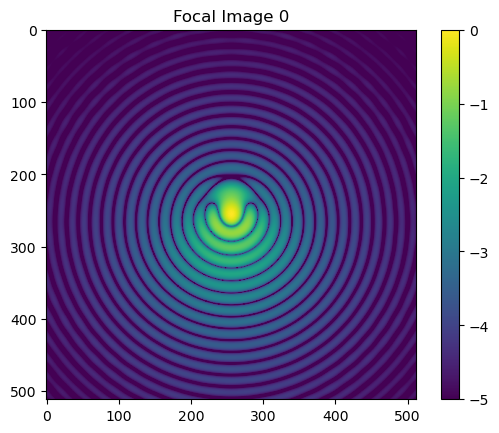

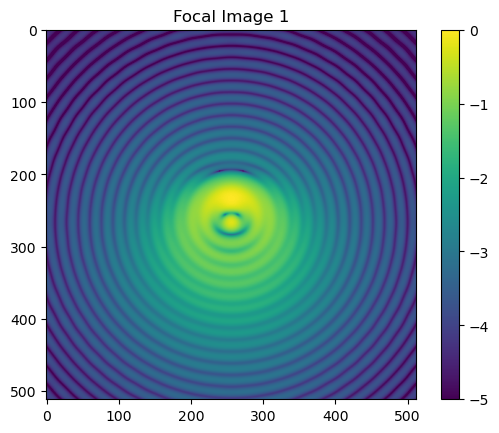

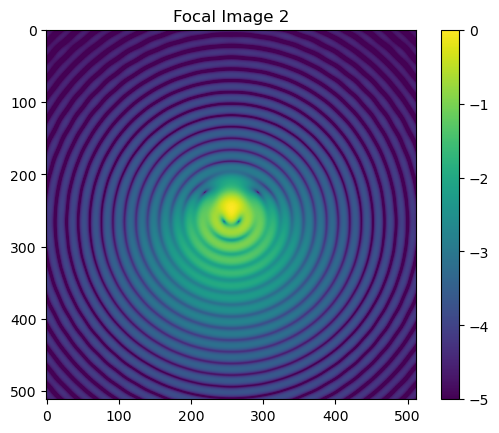

In [23]:
# Like Professor said, equal distances apart
#Defensive Programming - Look into it
#Use scale factors that Jules used to compare
scales = [2,1]
         
psf_list, distance_list, dx_list = generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength)

# Output the lists
print("PSF List", psf_list)
print("Distance List:", distance_list)
print("DX List:", dx_list)
defocus_images(psf_list)



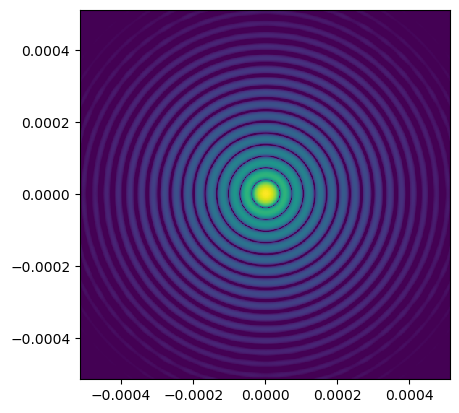

In [24]:
# Now let's start again with a clean wavefront 
clean_wf = wavefront = Wavefront(telescope_pupil, wavelength=650e-9)
clean_focal = prop_p2f(clean_wf)
imshow_field(np.log10(clean_focal.intensity / clean_focal.intensity.max()), vmin=-5)

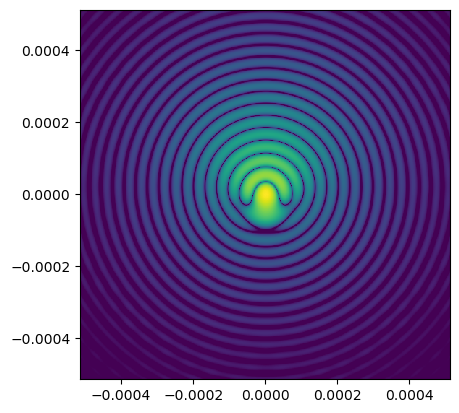

In [25]:
# And we need one example that's no defocus, just the abberation we are trying to sense

pupil_image.electric_field = np.exp(complex(0, 1)*(test_ab))*telescope_pupil
focal_image_0 = prop_p2f(pupil_image)
imshow_field(np.log10(focal_image_0.intensity / focal_image_0.intensity.max()), vmin=-5)

In [26]:
# Okay, let's run the phase diversity algorithm!
# if this import doesn't work, note that we had to add the path manually
# the command to do this should be sourced in your bash profile
from image_sharpening import FocusDiversePhaseRetrieval, ft_rev, mft_rev, InstrumentConfiguration

mp = FocusDiversePhaseRetrieval(psf_list,650e-3,dx_list,distance_list)
test_phase = 0
for i in range(200):
    psf00 = mp.step() # returns a model of the first PSF

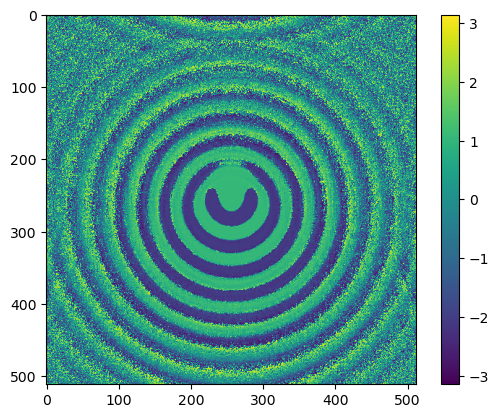

In [27]:
# Now let's inspect the output intensity -- just to make sure things look like we expect
# This should match the input no-defocus focal plane image

plt.imshow(np.angle(psf00))
plt.colorbar()

(512, 512)


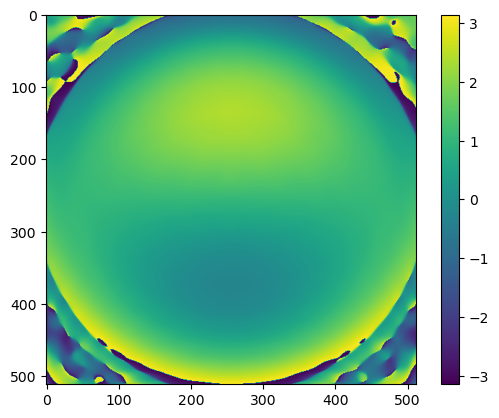

In [28]:
# Now we define a special dictionary with SEAL params which will let us do a fourier transform

seal_params = {'image_dx': 2.0071, # 
               'efl': focal_length*1e3, # SEAL effective focal length, mm
               'wavelength': 0.65, # SEAL center wavelength, microns
                'pupil_size': pupil_size*1e3, # Keck entrance pupil diameter
                    }
conf = InstrumentConfiguration(seal_params)

# Take a fourier transform to convert this to the pupil plane 
# I think something about the simulation output does not play as well with hcipy 
# so this is the best way to get pupil plane phase for now
raw_pupil_phase = np.angle(mft_rev(psf00, conf))
plt.imshow(raw_pupil_phase)
plt.colorbar()
print(f'{raw_pupil_phase.shape}')
# hmmm, this is hard to parse so ...

P2V error: 3.9637873266403276
(256, 256)


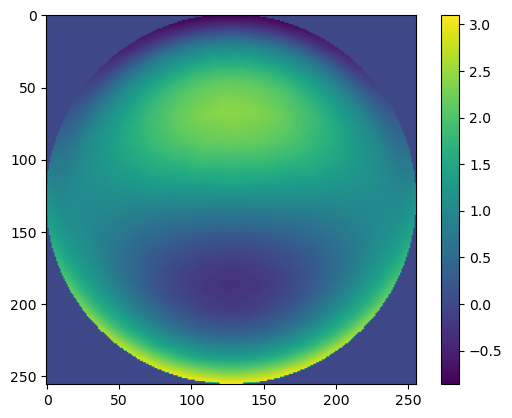

In [34]:
# We need to resize the image to our desired output and let's crop out the noise outside of the pupil 

from skimage.transform import resize
pupil_phase = resize(raw_pupil_phase, (256, 256))*telescope_pupil.shaped
plt.imshow(pupil_phase)
plt.colorbar()
print(f'P2V error: {np.max(pupil_phase) - np.min(pupil_phase)}')
print(f'{pupil_phase.shape}')
# NOW it looks pretty good..

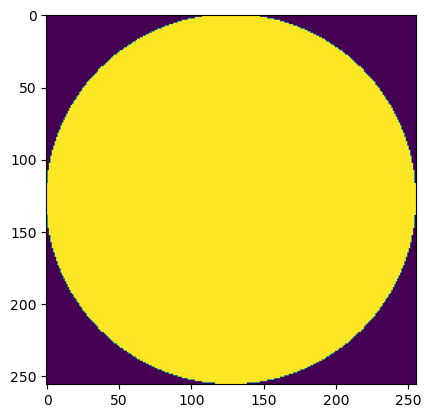

In [30]:
plt.imshow(telescope_pupil.shaped)
#1's where puil is, 0 where pupil isnt to remove edges and effects
#take median of image and than pull out only pixels inside pupil
##use boolean arrays, exists or not because using 1's and 0's respective to T and F
#index existing image as boolean array and spits out values we want
#So use multiplication for visual componenets, numerical indexing for number comparisons(taking a median)
#beginining two images, end goal is rms difference b/w both
##ensure they have same zero point,
#take median of pixels inside pupil and subtract it from that image to have phase have saem zero point as injection
#take the difference
#looks at rms error of pixels only inside pupil

P2V error: 4.212526089508674


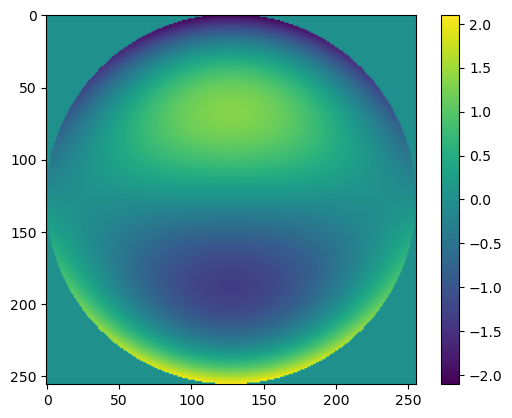

In [31]:
# Compare to the original error we injected and are trying to recover 
pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*(test_ab))
plt.imshow(unwrap_phase(pupil_image.phase.shaped))
plt.colorbar()
print(f'P2V error: {np.max(pupil_image.phase.shaped) - np.min(pupil_image.phase.shaped)}')

In [35]:


check_med= ma.shape(med_subtracted)
print(check_med)
check_differece= ma.shape(difference_image)
print(check_differece)
check_pupil_image= ma.shape(pupil_image.phase.shaped)
print(check_pupil_image)
check_masking_pupil= ma.shape(masking_pupil.shaped)
print(check_masking_pupil)

NameError: name 'med_subtracted' is not defined

Median error of 0.001564824423961525 radians.
Median error in nano: 0.1618822023938629nm


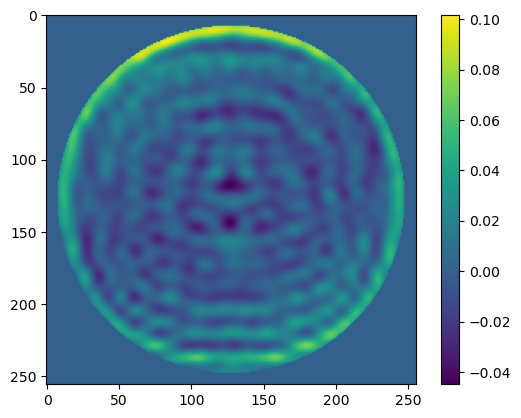

In [36]:
# And finally, lets see how well the reconstruction and the original input compare 
# Looks pretty good??? 
## CHeck with other examples for the diff functions
#Orkid cant move more than 100mm
#Unwrapping might be trivial, yayyyy jules!
med_subtracted = pupil_phase - np.median(pupil_phase[np.array(masking_pupil.shaped, dtype=bool)])
difference_image= pupil_image.phase.shaped - med_subtracted
plt.imshow(difference_image * masking_pupil.shaped)
plt.colorbar()
check_error_region = (pupil_image.phase.shaped - med_subtracted)[np.array(masking_pupil.shaped, dtype=bool)]
#here is the indexing
print(f'Median error of {np.median(check_error_region)} radians.')
nm_med = phase_to_m(np.median(check_error_region),650e-9)*1e9
print(f'Median error in nano: {(nm_med)}nm')



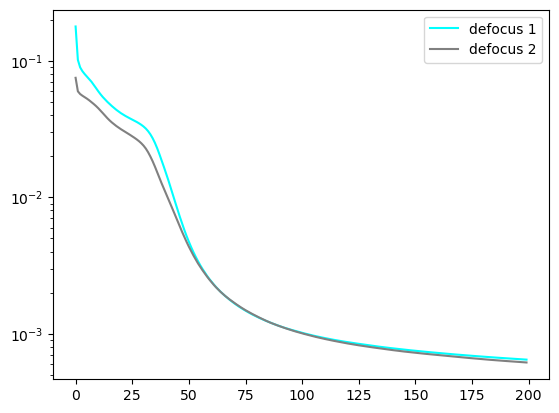

In [37]:
# We can also check how well the cost function of the algorithm is converging, this is a good diagnostic
# The cost function for all three images is converging so this looks good
plt.semilogy(mp.cost_functions[0], label='defocus 1', color='cyan')
plt.semilogy(mp.cost_functions[1], label='defocus 2', color='grey')
#plt.semilogy(mp.cost_functions[2], label='defocus 3', color='teal')
plt.legend()
plt.show()

In [40]:
print(f"Shape of pupil_phase: {pupil_phase.shape}")
print(f"Shape of telescope_pupil: {telescope_pupil.shape}")
print(f'{difference_image.shape}')

if telescope_pupil.ndim == 1:
    telescope_pupil = telescope_pupil.reshape(pupil_phase.shape)


valid_phase_values = med_subtracted[telescope_pupil > 0]

#Calculate the mean of the valid phase values
mean_phase = np.mean(valid_phase_values)

#Calculate the RMS error
rms_error = np.sqrt(np.mean((valid_phase_values - mean_phase) ** 2))

print(f"RMS error: {rms_error} radians")

Shape of pupil_phase: (256, 256)
Shape of telescope_pupil: (256, 256)
(256, 256)
RMS error: 0.7467130245522918 radians


In [ ]:
# as a treat, if we need an alternative phase wrapping routine ...
# different phase unwrapping routine take from Jaren
def phase_unwrap_2d(phase_wrapped):

    """phase unwrapping routine based on the phaseunwrap2d.go script in IDL and the following proceedings:
    M.D. Pritt; J.S. Shipman, "Least-squares two-dimensional phase unwrapping using FFT's",
    IEEE Transactions on Geoscience and Remote Sensing ( Volume: 32, Issue: 3, May 1994),
    DOI: 10.1109/36.297989

    Uses a finite differences approach to determine the partial derivative of the wrapped phase in x and y,
    then solves the solution in the fourier domain

    TODO: Test this function against the prior in IDL, it doesn't appear to reconstruct phase well

    Parameters
    ----------
    phase_wrapped : numpy.ndarray
        array containing 2D signal to unwrap

    Returns
    -------
    numpy.ndarray
        unwrapped phase
    """

    imsize = phase_wrapped.shape
    M = imsize[0]
    N = imsize[1]

    Nmirror = 2 * (N )
    Mmirror = 2 * (M )

    phmirror = np.ones([Mmirror,Nmirror])

    # Quadrant 3
    phmirror[:M,:N] = phase_wrapped

    # First mirror reflection Quadrant 2
    phmirror[M:,:N] = np.flipud(phase_wrapped)

    # Second mirror reflection Quadrant 4
    phmirror[:M,N:] = np.fliplr(phase_wrapped)

    # Final reflection Quadrant 1
    phmirror[M:,N:] = np.flipud(np.fliplr(phase_wrapped))

    phroll = np.zeros_like(phmirror)
    phroll[:M,:N-1] = phmirror[:M,1:N]
    phroll[:M,N-1] = phmirror[:M,0]
    deltafd = phroll-phmirror

    pluspi = np.pi*np.ones_like(phmirror)
    mask = (deltafd > pluspi).astype(int)

    deltafd = deltafd - mask*2*np.pi
    negpi = -pluspi
    mask = (deltafd < negpi).astype(int)
    deltafd = deltafd + mask * 2 * np.pi
    deltafdx = deltafd

    # compute forward difference
    phroll = np.zeros_like(phmirror)
    phroll[:M-1,:N] = phmirror[1:M,:N]
    phroll[M,:N] = phmirror[0,:N]
    deltafd = phroll - phmirror

    pluspi = np.pi*np.ones_like(phmirror)
    mask = (deltafd > pluspi).astype(int)
    deltafd = deltafd - mask*2*np.pi
    negpi = -pluspi
    mask = (deltafd < negpi).astype(int)
    deltafd = deltafd + mask * 2 * np.pi
    deltafdy = deltafd

    # Solve system of equations formed by min LS -> phi
    D_n = np.fft.fft2(deltafdx)
    D_m = np.fft.fft2(deltafdy)
    inc_n = 2 * np.pi / Nmirror
    inc_m = 2 * np.pi / Mmirror

    nn = np.ones([Mmirror,1]) @ (np.arange(Nmirror))[np.newaxis]
    mm = np.ones([Nmirror,1]) @ (np.arange(Mmirror))[np.newaxis]
    mm = mm.transpose()
    
    i = 1j
    mult_n = np.ones([Mmirror,Nmirror]) - np.exp(-nn * i * inc_n)
    mult_m = np.ones([Mmirror,Nmirror]) - np.exp(-mm * i * inc_m)
    divisor = (np.cos(mm*inc_m) + np.cos(nn*inc_n) - np.ones([Mmirror,Nmirror])*2)*2
    divisor[0,0] = 1
    phi = (D_n*mult_n + D_m*mult_m) / divisor
    phi[0,0] = 0
    phi = np.fft.ifft2(phi)[:M,:N]
    phout = np.real(phi)
    return phout